# In this notebook we plot the selected storms.
They are selected using the SYM-H index to not have a bias toward any station

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import storm_dates
import utils
import constants
sns.set_style("whitegrid")

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
solar_wind_data_path = './data/all_timeline'
stations_data_path = './data/stations_data_magnetic.csv'
stations_data = pd.read_csv(stations_data_path)
sym_data = utils.read_data(solar_wind_data_path, pattern_to_read=['omni'])
sym_data = pd.concat(sym_data)
sym_data = sym_data.sort_index()

In [3]:
colors = [
    '#FF0000',  # Red
    '#00FF00',  # Green
    '#FFA500',  # Orange
    '#800080',  # Purple
    '#00FFFF',  # Cyan
    '#FF00FF',  # Magenta
    'gold',  # Yellow
    '#A52A2A',  # Brown
    'lawngreen',  # Black,
    'darkviolet',
    'royalblue'
]

Thresholds obtained from https://link.springer.com/article/10.1007/s11069-023-06241-1

In [4]:
th_low = -90
th_moderate = -130
th_intense = -230
th_superintense = -390

In [5]:
def from_peak_to_intensity(peak):
    if peak < th_superintense:
        return "superintense"
    elif peak < th_intense:
        return "intense"
    elif peak < th_moderate:
        return "moderate"
    else:
        return "low"

In [6]:
summary_dfs = [pd.DataFrame(columns=['Start date', 'End date', 'Duration', 'SYM-H peak', 'classification'])
               for _ in range(3)]

for i, (sdates, df) in enumerate(zip(
        [storm_dates.TRAIN_STORMS, storm_dates.VALIDATION_STORMS, storm_dates.TEST_STORMS], 
        summary_dfs)):
    
    for start_date, end_date, index in sdates:
        sd = pd.to_datetime(start_date)
        ed = pd.to_datetime(end_date)
        symh_slice = sym_data.loc[sd:ed]['SYM_H']
        new_row = pd.DataFrame({
            'Start date': [sd],
            'End date': [ed],
            'Duration': [ed - sd],
            'SYM-H peak': [symh_slice.min()],
            'classification': [from_peak_to_intensity(symh_slice.min())]
        })
        summary_dfs[i] = pd.concat([summary_dfs[i], new_row], ignore_index=True)

# Unpack them at the end
summary_df_train, summary_df_val, summary_df_test = summary_dfs


/tmp/ipykernel_2890040/317892305.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_dfs[i] = pd.concat([summary_dfs[i], new_row], ignore_index=True)


In [7]:
for df, df_name in zip([summary_df_train, summary_df_val, summary_df_test], ['Train', 'Validation', 'Test']):
    print(f"{df_name} storms summary:")
    print(df['classification'].value_counts())    
    print("\n")

Train storms summary:
classification
low             35
moderate        24
intense          7
superintense     3
Name: count, dtype: int64


Validation storms summary:
classification
moderate        9
low             7
intense         2
superintense    1
Name: count, dtype: int64


Test storms summary:
classification
moderate        10
low              8
intense          2
superintense     1
Name: count, dtype: int64




In [8]:
storms_dates_df = pd.DataFrame(columns=['Storm Index', 'Start date', 'End date', 'SYM-H peak', 'classification'])
for start_date, end_date, storm_index in storm_dates.TRAIN_STORMS:
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    symh_slice = sym_data[sd:ed]['SYM_H']
    new_row = pd.DataFrame({
        'Storm Index': [storm_index],
        'Start date': [sd],
        'End date': [ed],
        'SYM-H peak': [symh_slice.min()],
        'classification': [from_peak_to_intensity(symh_slice.min())]
    })
    storms_dates_df = pd.concat([storms_dates_df, new_row], ignore_index=True)
    
latex_str = storms_dates_df.set_index('Storm Index').assign(
    Start_date=lambda df: df['Start date'].dt.strftime('%Y-%m-%d'),
    End_date=lambda df: df['End date'].dt.strftime('%Y-%m-%d'),
    classification=lambda df: df['classification'].str.capitalize()
)[['Start_date', 'End_date', 'SYM-H peak', 'classification']].to_latex(index=True)
print(latex_str)

\begin{tabular}{lllll}
\toprule
 & Start_date & End_date & SYM-H peak & classification \\
Storm Index &  &  &  &  \\
\midrule
1 & 1998-03-08 & 1998-03-17 & -119 & Low \\
2 & 1998-05-02 & 1998-05-11 & -268 & Intense \\
3 & 1998-06-24 & 1998-07-02 & -120 & Low \\
4 & 1998-08-04 & 1998-08-13 & -168 & Moderate \\
5 & 1998-08-25 & 1998-09-02 & -171 & Moderate \\
6 & 1998-09-23 & 1998-10-01 & -213 & Moderate \\
7 & 1998-10-17 & 1998-10-25 & -120 & Low \\
8 & 1999-01-11 & 1999-01-20 & -111 & Low \\
9 & 1999-02-16 & 1999-02-25 & -127 & Low \\
10 & 1999-02-27 & 1999-03-07 & -93 & Low \\
11 & 1999-04-15 & 1999-04-23 & -122 & Low \\
12 & 1999-09-20 & 1999-09-29 & -160 & Moderate \\
13 & 2000-02-10 & 2000-02-18 & -164 & Moderate \\
14 & 2000-05-15 & 2000-05-30 & -159 & Moderate \\
15 & 2000-06-06 & 2000-06-14 & -90 & Low \\
16 & 2000-07-13 & 2000-07-26 & -335 & Intense \\
17 & 2000-08-09 & 2000-08-18 & -235 & Intense \\
18 & 2000-09-15 & 2000-09-24 & -196 & Moderate \\
19 & 2000-10-02 & 2000-10-20

/tmp/ipykernel_2890040/2818536205.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  storms_dates_df = pd.concat([storms_dates_df, new_row], ignore_index=True)


In [9]:
storms_dates_df = pd.DataFrame(columns=['Storm Index', 'Start date', 'End date', 'SYM-H peak', 'classification'])
for start_date, end_date, storm_index in storm_dates.VALIDATION_STORMS:
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    symh_slice = sym_data[sd:ed]['SYM_H']
    new_row = pd.DataFrame({
        'Storm Index': [storm_index],
        'Start date': [sd],
        'End date': [ed],
        'SYM-H peak': [symh_slice.min()],
        'classification': [from_peak_to_intensity(symh_slice.min())]
    })
    storms_dates_df = pd.concat([storms_dates_df, new_row], ignore_index=True)
    
latex_str = storms_dates_df.set_index('Storm Index').assign(
    Start_date=lambda df: df['Start date'].dt.strftime('%Y-%m-%d'),
    End_date=lambda df: df['End date'].dt.strftime('%Y-%m-%d'),
    classification=lambda df: df['classification'].str.capitalize()
)[['Start_date', 'End_date', 'SYM-H peak', 'classification']].to_latex(index=True)
print(latex_str)

/tmp/ipykernel_2890040/421070927.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  storms_dates_df = pd.concat([storms_dates_df, new_row], ignore_index=True)


\begin{tabular}{lllll}
\toprule
 & Start_date & End_date & SYM-H peak & classification \\
Storm Index &  &  &  &  \\
\midrule
70 & 1999-10-20 & 1999-10-28 & -218 & Moderate \\
71 & 2000-01-21 & 2000-01-29 & -101 & Low \\
72 & 2000-04-04 & 2000-04-13 & -315 & Intense \\
73 & 2001-03-29 & 2001-04-08 & -434 & Superintense \\
74 & 2002-05-09 & 2002-05-18 & -109 & Low \\
75 & 2002-08-19 & 2002-08-27 & -119 & Low \\
76 & 2003-06-16 & 2003-06-24 & -162 & Moderate \\
77 & 2005-07-08 & 2005-07-16 & -113 & Low \\
78 & 2005-09-09 & 2005-09-17 & -135 & Moderate \\
79 & 2011-10-23 & 2011-10-31 & -160 & Moderate \\
80 & 2012-09-29 & 2012-10-19 & -138 & Moderate \\
81 & 2013-03-15 & 2013-03-24 & -131 & Moderate \\
82 & 2013-06-27 & 2013-07-05 & -110 & Low \\
83 & 2014-02-17 & 2014-03-06 & -125 & Low \\
84 & 2015-03-15 & 2015-03-25 & -233 & Intense \\
85 & 2015-06-20 & 2015-06-29 & -207 & Moderate \\
86 & 2015-08-25 & 2015-09-03 & -100 & Low \\
87 & 2015-12-18 & 2015-12-27 & -169 & Moderate \\
88 & 20

In [10]:
storms_dates_df = pd.DataFrame(columns=['Storm Index', 'Start date', 'End date', 'SYM-H peak', 'classification'])
for start_date, end_date, storm_index in storm_dates.TEST_STORMS:
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    symh_slice = sym_data[sd:ed]['SYM_H']
    new_row = pd.DataFrame({
        'Storm Index': [storm_index],
        'Start date': [sd],
        'End date': [ed],
        'SYM-H peak': [symh_slice.min()],
        'classification': [from_peak_to_intensity(symh_slice.min())]
    })
    storms_dates_df = pd.concat([storms_dates_df, new_row], ignore_index=True)
    
display(storms_dates_df)

/tmp/ipykernel_2890040/2237588545.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  storms_dates_df = pd.concat([storms_dates_df, new_row], ignore_index=True)


,Storm Index,Start date,End date,SYM-H peak,classification
0,89,2017-09-06,2017-09-15,-144,moderate
1,90,2017-09-26,2017-10-04,-74,low
2,91,2018-08-24,2018-09-01,-205,moderate
3,92,2021-11-02,2021-11-10,-117,low
4,93,2022-01-12,2022-01-20,-100,low
5,94,2022-11-05,2022-11-13,-116,low
6,95,2023-02-25,2023-03-06,-161,moderate
7,96,2023-03-21,2023-03-30,-170,moderate
8,97,2023-04-21,2023-04-30,-231,intense
9,98,2023-08-03,2023-08-11,-103,low


In [11]:
latex_str = storms_dates_df.set_index('Storm Index').assign(
    Start_date=lambda df: df['Start date'].dt.strftime('%Y-%m-%d'),
    End_date=lambda df: df['End date'].dt.strftime('%Y-%m-%d'),
    classification=lambda df: df['classification'].str.capitalize()
)[['Start_date', 'End_date', 'SYM-H peak', 'classification']].to_latex(index=True)
print(latex_str)

\begin{tabular}{lllll}
\toprule
 & Start_date & End_date & SYM-H peak & classification \\
Storm Index &  &  &  &  \\
\midrule
89 & 2017-09-06 & 2017-09-15 & -144 & Moderate \\
90 & 2017-09-26 & 2017-10-04 & -74 & Low \\
91 & 2018-08-24 & 2018-09-01 & -205 & Moderate \\
92 & 2021-11-02 & 2021-11-10 & -117 & Low \\
93 & 2022-01-12 & 2022-01-20 & -100 & Low \\
94 & 2022-11-05 & 2022-11-13 & -116 & Low \\
95 & 2023-02-25 & 2023-03-06 & -161 & Moderate \\
96 & 2023-03-21 & 2023-03-30 & -170 & Moderate \\
97 & 2023-04-21 & 2023-04-30 & -231 & Intense \\
98 & 2023-08-03 & 2023-08-11 & -103 & Low \\
99 & 2023-11-03 & 2023-11-12 & -188 & Moderate \\
100 & 2023-11-23 & 2023-12-08 & -132 & Moderate \\
101 & 2024-03-01 & 2024-03-09 & -127 & Low \\
102 & 2024-03-22 & 2024-03-30 & -170 & Moderate \\
103 & 2024-04-17 & 2024-04-25 & -138 & Moderate \\
104 & 2024-04-30 & 2024-05-24 & -497 & Superintense \\
105 & 2024-06-26 & 2024-07-04 & -118 & Low \\
106 & 2024-08-02 & 2024-08-19 & -214 & Moderate \\


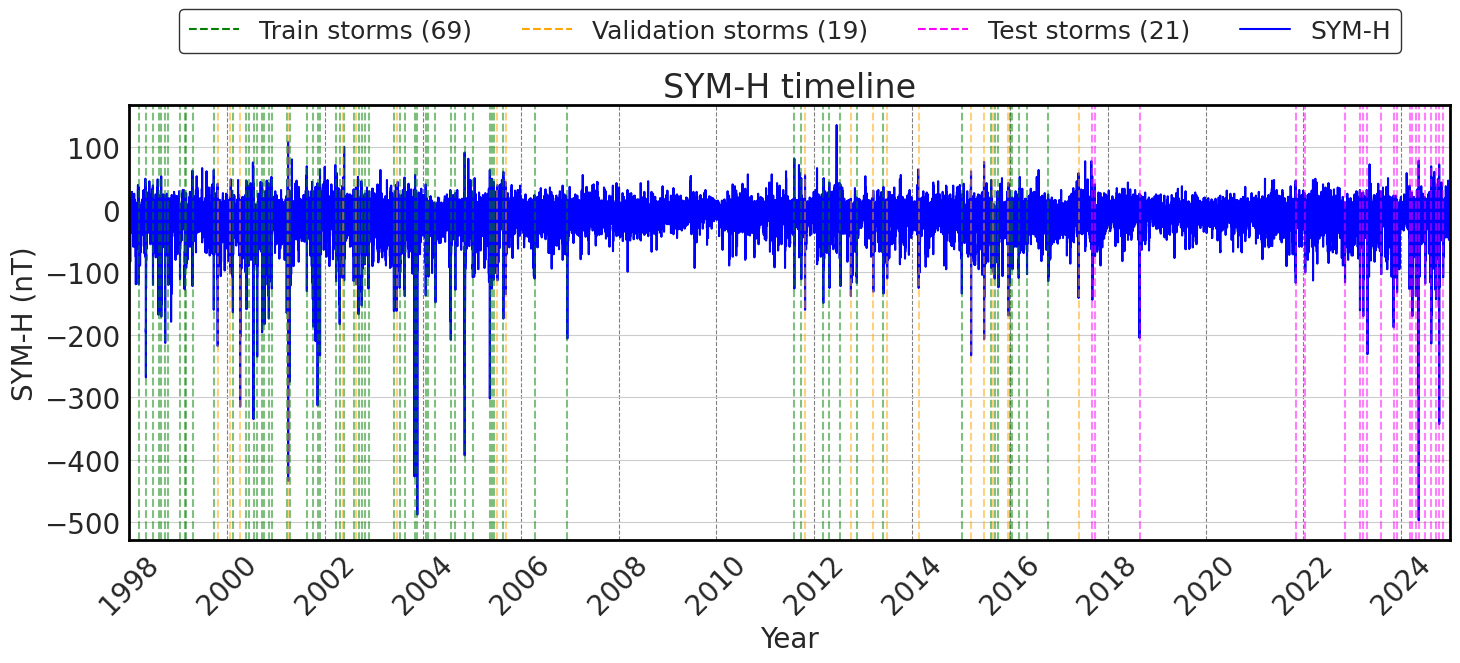

In [12]:
fig, ax = plt.subplots(1, 1, figsize = (15, 7));
ax.plot(sym_data.index, sym_data['SYM_H'], color = 'blue')

ax.set_xlim(
    sym_data.index[0], sym_data.index[-1]
)

ax.set_ylabel('SYM-H (nT)', fontsize = 20)
ax.set_xlabel('Year', fontsize = 20)

ax.grid(which='major', axis='x', linestyle='--', color='grey')

#plt.xticks(rotation = 45, fontsize = 12)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xticks(pd.date_range(start=sym_data.index[0], end=sym_data.index[-1], freq='2YS'))
ax.set_xticklabels(pd.date_range(start=sym_data.index[0], end=sym_data.index[-1], freq='2YS').year, rotation=45)
plt.setp(ax.spines.values(), lw=2, color="black", alpha=1)
# where some data has already been plotted to ax

handles, labels = ax.get_legend_handles_labels()

handles.append(plt.Line2D([0], [0], color='green', linestyle='--', label=f'Train storms ({len(storm_dates.TRAIN_STORMS)})'))
handles.append(plt.Line2D([0], [0], color='orange', linestyle='--', label=f'Validation storms ({len(storm_dates.VALIDATION_STORMS)})'))
handles.append(plt.Line2D([0], [0], color='magenta', linestyle='--', label=f'Test storms ({len(storm_dates.TEST_STORMS)})'))
handles.append(plt.Line2D([0], [0], color='blue', label=f'SYM-H'))

ax.set_title('SYM-H timeline' , fontsize = 24)

for sdates, color in zip([storm_dates.TRAIN_STORMS, storm_dates.VALIDATION_STORMS, storm_dates.TEST_STORMS], ['green', 'orange', 'magenta']):
    for start_date, end_date, index in sdates:
        sd = pd.to_datetime(start_date)
        ed = pd.to_datetime(end_date)
        peak_date = sym_data[sd:ed].idxmin()
        plt.axvline(peak_date, linestyle = '--', alpha = 0.5, color = color)

leg = ax.legend(
        handles=handles,
        ncol=len(handles),
        fancybox=True,
        prop={"size": 18},
        bbox_to_anchor=(0.5, 1.25),
        loc="upper center",
        edgecolor="black",
        facecolor="none"
    )
plt.tight_layout()
plt.savefig('./figs/storms-selection.png', transparent = True)

plt.show();

In [13]:
df_stations = pd.DataFrame(columns = ['Identifier', 'Full Name', 'Country', 'Magnetic Latitude (N)', 'Magnetic Longitude (E)'])
for station in constants.STATIONS:
    identifier = station
    full_name = stations_data[stations_data["IAGA_CODE"] == station]["NAME"].values[0]
    country = stations_data[stations_data["IAGA_CODE"] == station]["COUNTRY"].values[0]
    magnetic_latitude = stations_data[stations_data["IAGA_CODE"] == station]["LATITUDE_M"].values[0]
    magnetic_longitude = stations_data[stations_data["IAGA_CODE"] == station]["LONGITUDE_M"].values[0]
    df_stations = pd.concat([df_stations, pd.DataFrame({
        'Identifier': [identifier],
        'Full Name': [full_name],
        'Country': [country],
        'Magnetic Latitude (N)': [magnetic_latitude],
        'Magnetic Longitude (E)': [magnetic_longitude]
    })], ignore_index=True)
display(df_stations)

/tmp/ipykernel_2890040/1767950462.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_stations = pd.concat([df_stations, pd.DataFrame({


,Identifier,Full Name,Country,Magnetic Latitude (N),Magnetic Longitude (E)
0,ABG,Alibag,India,13.181692,146.097944
1,MMB,Memambetsu,Japan,37.290910,-142.784990
2,CLF,Chambon-la-Foret,France,42.758442,77.905287
3,TUC,Tucson,United States of America,39.372704,-43.095996
4,HON,Honolulu,United States of America,21.398408,-89.007854
5,SFS,San Fernando,Spain,26.523421,69.231392
